# Exploratory experiments

Scratch notebook for model probing and qualitative checks (not tied to a paper table). All paths below are repo-relative: point the checkpoint / data paths at your own trained weights and datasets. The reproducible, paper-aligned benchmarks live in `benchmarking/`.


In [11]:
import torch
import sys
from pathlib import Path

src_path = "../"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
from src.model import TransformDecoder, ImageTransformPredictor
from src.dataset import ImageTransformer, TransformTokenizer, TRANSFORM_TOKENS
from src.dataset import DomainNetDataset, get_domainnet_dataloaders
from PIL import Image
from omegaconf import OmegaConf
from torchvision import transforms
import os

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# !pip install efficientnet-pytorch

```
pip install --no-cache-dir \
  "torch==2.3.1" \
  "torchvision==0.18.1" \
  "torchaudio==2.3.1" \
  --index-url https://download.pytorch.org/whl/cu118
```

In [ ]:
# pip install --no-cache-dir \
#   "torch==2.3.1" \
#   "torchvision==0.18.1" \
#   "torchaudio==2.3.1" \
#   --index-url https://download.pytorch.org/whl/cu118

### Models

#### Image Pair Encoder

In [8]:
preprocess = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

# preprocess = transforms.Compose([
#             transforms.Resize((300, 300)),
#             transforms.ToTensor(),
#             transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
#         ])

#### Transform Decoder

In [9]:
config = OmegaConf.load('../configs/train_config_vit.yaml')
decoder = TransformDecoder(config.model.decoder)

embs = torch.rand(1, 1, 512)

decoder.eval()
with torch.no_grad():
    seq = decoder.generate(embs, max_new_tokens=12, do_sample=True)
seq.shape
print(seq)

tensor([[ 1,  5, 10,  9,  4,  4,  7, 12,  2,  0,  0,  0,  0]])


In [10]:
idx = torch.tensor([[1, 3, 5, 2, 0]])
targets = torch.tensor([[3, 5, 2, 0, 0]])
logits, loss = decoder(idx, embs, targets)

logits.shape

torch.Size([1, 5, 14])

#### Image Transform Predictor

In [13]:
config = OmegaConf.load('../configs/train_config_vit.yaml')

model = ImageTransformPredictor(config.model)

checkpoint_path = "PATH/2/CHECKPOINT"

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.to('cuda')
model.eval()
print('ready')

ready


In [ ]:
# !pip install torchvision==0.18.1+cu121 --extra-index-url https://download.pytorch.org/whl/cu121

### First tests

['color_jitter', 'rotate_270']


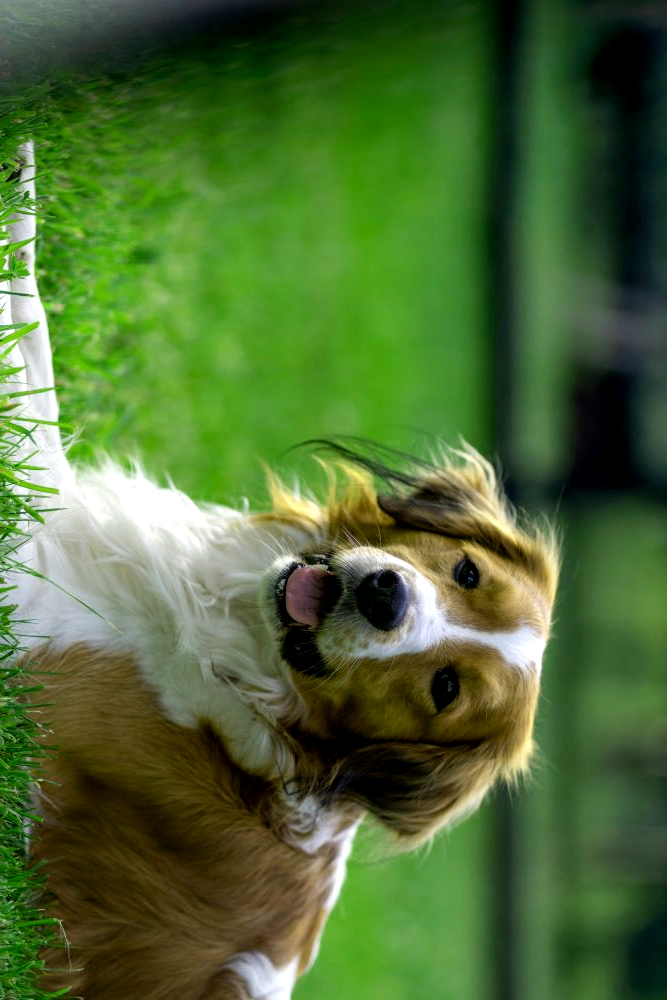

In [14]:
image_path_1 = '../assets/image.jpg'
image_path_2 = '../assets/dog.jpg'

image_1 = Image.open(image_path_1)
image_2 = Image.open(image_path_2)

it = ImageTransformer()
transformed_image_1, sequence_1 = it.transform(image_1, p=0.3)
print(sequence_1)
transformed_image_1

In [15]:
image_tensor_1 = preprocess(image_1).unsqueeze(0)
image_tensor_2 = preprocess(image_2).unsqueeze(0)
transformed_image_tensor = preprocess(transformed_image_1).unsqueeze(0)

generated = model.generate(image_tensor_1.to('cuda'), transformed_image_tensor.to('cuda'), max_new_tokens=10, do_sample=False)

print(generated)

tensor([[1, 7, 8, 2, 0, 0, 0, 0, 0, 0, 0]], device='cuda:0')


In [16]:
tokenizer = TransformTokenizer()
tokens = tokenizer.decode(generated[0], skip_special_tokens=True)
print(f"Predicted: {tokens}")
print(f"Target: {sequence_1}")

Predicted: ['rotate_270', 'color_jitter']
Target: ['color_jitter', 'rotate_270']


In [17]:
logits = model(transformed_image_tensor.to('cuda'), image_tensor_1.to('cuda'), torch.tensor([[1]]).to('cuda'))
logits = logits[0][0]
logits[:, model.pad_token_id] = -float('inf')
logits[:, model.bos_token_id] = -float('inf')
probs = torch.exp(logits) / torch.exp(logits).sum(dim=-1, keepdim=True)
p_eos = probs[:, 2]
similarities = 1.0 - p_eos
similarities.item()

0.9999939799308777

#### Attention visualization

In [18]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from typing import Union, List, Tuple, Optional

# ------------------- Утилиты для обработки внимания -------------------

def split_vit_cross_attn(attn: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Split cross-attention weights for ViT-B/16 pair encoding:
        L = 395 = 197 (img1) + 1 (sep) + 197 (img2)
        Each 197 = 1 (CLS) + 196 (patches)
    """
    # attn: [B, H, L=395]
    cls1 = attn[:, :, 0:1]          # [B, H, 1]
    patches1 = attn[:, :, 1:197]    # [B, H, 196]
    sep = attn[:, :, 197:198]       # [B, H, 1]
    cls2 = attn[:, :, 198:199]      # [B, H, 1]
    patches2 = attn[:, :, 199:395]  # [B, H, 196]
    return cls1, patches1, sep, patches2, cls2

def patches_to_heatmap_tensor(patches: torch.Tensor, target_size: int = 224) -> torch.Tensor:
    """
    Convert [B, H, 196] → [B, H, 14, 14] → upsample → [B, H, target_size, target_size]
    Then avg over heads → [B, target_size, target_size]
    """
    B, n_heads, _ = patches.shape
    patches_grid = patches.view(B, n_heads, 14, 14)
    patches_up = F.interpolate(
        patches_grid, size=(target_size, target_size),
        mode='bilinear', align_corners=False
    )  # [B, H, S, S]
    heatmap = patches_up.mean(dim=1)  # [B, S, S] — avg over heads
    return heatmap

def normalize_heatmap(hm: torch.Tensor) -> torch.Tensor:
    """Normalize per sample to [0, 1]"""
    min_val = hm.amin(dim=(-2, -1), keepdim=True)
    max_val = hm.amax(dim=(-2, -1), keepdim=True)
    return (hm - min_val) / (max_val - min_val + 1e-8)

# ------------------- Визуализация -------------------

def visualize_cross_attention_step(
    model: torch.nn.Module,
    image1: Union[str, Image.Image, torch.Tensor],
    image2: Union[str, Image.Image, torch.Tensor],
    idx_prefix: Optional[torch.Tensor] = None,
    title: str = "Cross-Attention for Next Token Prediction",
    return_tensors: bool = False,
):
    """
    Run one generation step and visualize where decoder attends in each image.

    Args:
        model: ImageTransformPredictor (must use ViT encoder)
        image1, image2: path, PIL.Image, or [3, H, W] tensor (0–1 or 0–255, auto-normalized)
        idx_prefix: optional prompt tokens (e.g., [BOS, rotate, 90]); if None --> [BOS]
        title: plot title
        return_tensors: if True, returns (orig1, orig2, hm1, hm2) instead of plotting

    Output:
        Shows 2x2 plot: orig1, orig2, hm1+orig1, hm2+orig2
    """
    id_to_token = {
        0: "[PAD]",
        1: "[START]",
        2: "[END]",
        3: "noop",
        4: "grayscale",
        5: "rotate_90",
        6: "rotate_180",
        7: "rotate_270",
        8: "color_jitter",
        9: "noise_adding",
        10: "crop",
        11: "horizontal_flip",
        12: "vertical_flip",
        13: "jpeg_artefacts",
    }
    # --- Load & preprocess images ---
    def load_image(img) -> torch.Tensor:
        if isinstance(img, str):
            img = Image.open(img).convert("RGB")
        if isinstance(img, Image.Image):
            img = transforms.ToTensor()(img)  # [3, H, W], 0–1
        if img.dtype == torch.uint8:
            img = img.float() / 255.0
        return img

    img1 = load_image(image1)
    img2 = load_image(image2)

    # Ensure batch dim
    if img1.ndim == 3:
        img1 = img1.unsqueeze(0)
        img2 = img2.unsqueeze(0)

    # Preprocess for ViT (ImageNet norm + resize 224)
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    img1_proc = preprocess(img1)
    img2_proc = preprocess(img2)

    # --- Run model step ---
    model.eval()

    logits, next_token, cross_attn = model.generate_step_with_cross_attn(
        image_batch_1=img1_proc,
        image_batch_2=img2_proc,
        idx_prefix=idx_prefix,
    )

    # Use last layer attention (most semantic)
    attn_last_layer = cross_attn[-1]  # [B, n_head, 395]

    # Split and convert patches → heatmaps
    _, patches1, _, patches2, _ = split_vit_cross_attn(attn_last_layer)
    hm1 = normalize_heatmap(patches_to_heatmap_tensor(patches1))  # [B, 224, 224]
    hm2 = normalize_heatmap(patches_to_heatmap_tensor(patches2))

    # Take first sample
    orig1 = img1[0].cpu()
    orig2 = img2[0].cpu()
    hm1 = hm1[0].cpu()
    hm2 = hm2[0].cpu()

    if return_tensors:
        return orig1, orig2, hm1, hm2

    # --- Plot ---
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    plt.suptitle(title + f"\nPredicted next transformation token: ID {next_token[0].item()}, {id_to_token[next_token[0].item()]}", fontsize=14)

    # Originals
    axes[0, 0].imshow(orig1.permute(1, 2, 0))
    axes[0, 0].set_title("Image 1")
    axes[0, 0].axis('off')

    axes[0, 1].imshow(orig2.permute(1, 2, 0))
    axes[0, 1].set_title("Image 2")
    axes[0, 1].axis('off')

    # Heatmaps overlay
    axes[1, 0].imshow(orig1.permute(1, 2, 0))
    axes[1, 0].imshow(hm1, cmap='jet', alpha=0.5)
    axes[1, 0].set_title("Attention on Image 1 (patches)")
    axes[1, 0].axis('off')

    axes[1, 1].imshow(orig2.permute(1, 2, 0))
    axes[1, 1].imshow(hm2, cmap='jet', alpha=0.5)
    axes[1, 1].set_title("Attention on Image 2 (patches)")
    axes[1, 1].axis('off')

    plt.tight_layout()
    # plt.savefig("assets/attention_2.pdf")
    plt.show()

In [20]:
plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'lines.linewidth': 1.5,
    'lines.markersize': 8,
    'grid.alpha': 0.3,
    'figure.dpi': 300,
    'font.weight': 'normal',
})


visualize_cross_attention_step(
    model,
    image1=image_1.resize((224, 224)),
    image2=transformed_image_1.resize((224, 224)),
    idx_prefix=torch.tensor([[1]])
)

In [ ]:
# plt.savefig("assets/attention.pdf")

#### t-SNE visualization of transform tokens

In [24]:
model.to('cpu')
token_embedding = model.transform_decoder.token_embedding.weight
token_embedding.shape

torch.Size([14, 512])

In [32]:
vectors_np = token_embedding.detach().numpy()
num_vectors = 14

INVERTED_TRANSFORM_TOKENS = {
    0: "[PAD]",
    1: "[START]",
    2: "[END]",
    3: "noop",
    4: "grayscale",
    5: "rotate_90",
    6: "rotate_180",
    7: "rotate_270",
    8: "color_jitter",
    9: "noise_adding",
    10: "crop",
    11: "horizontal_flip",
    12: "vertical_flip",
    13: "jpeg_artefacts"
}

In [33]:
# !pip install seaborn

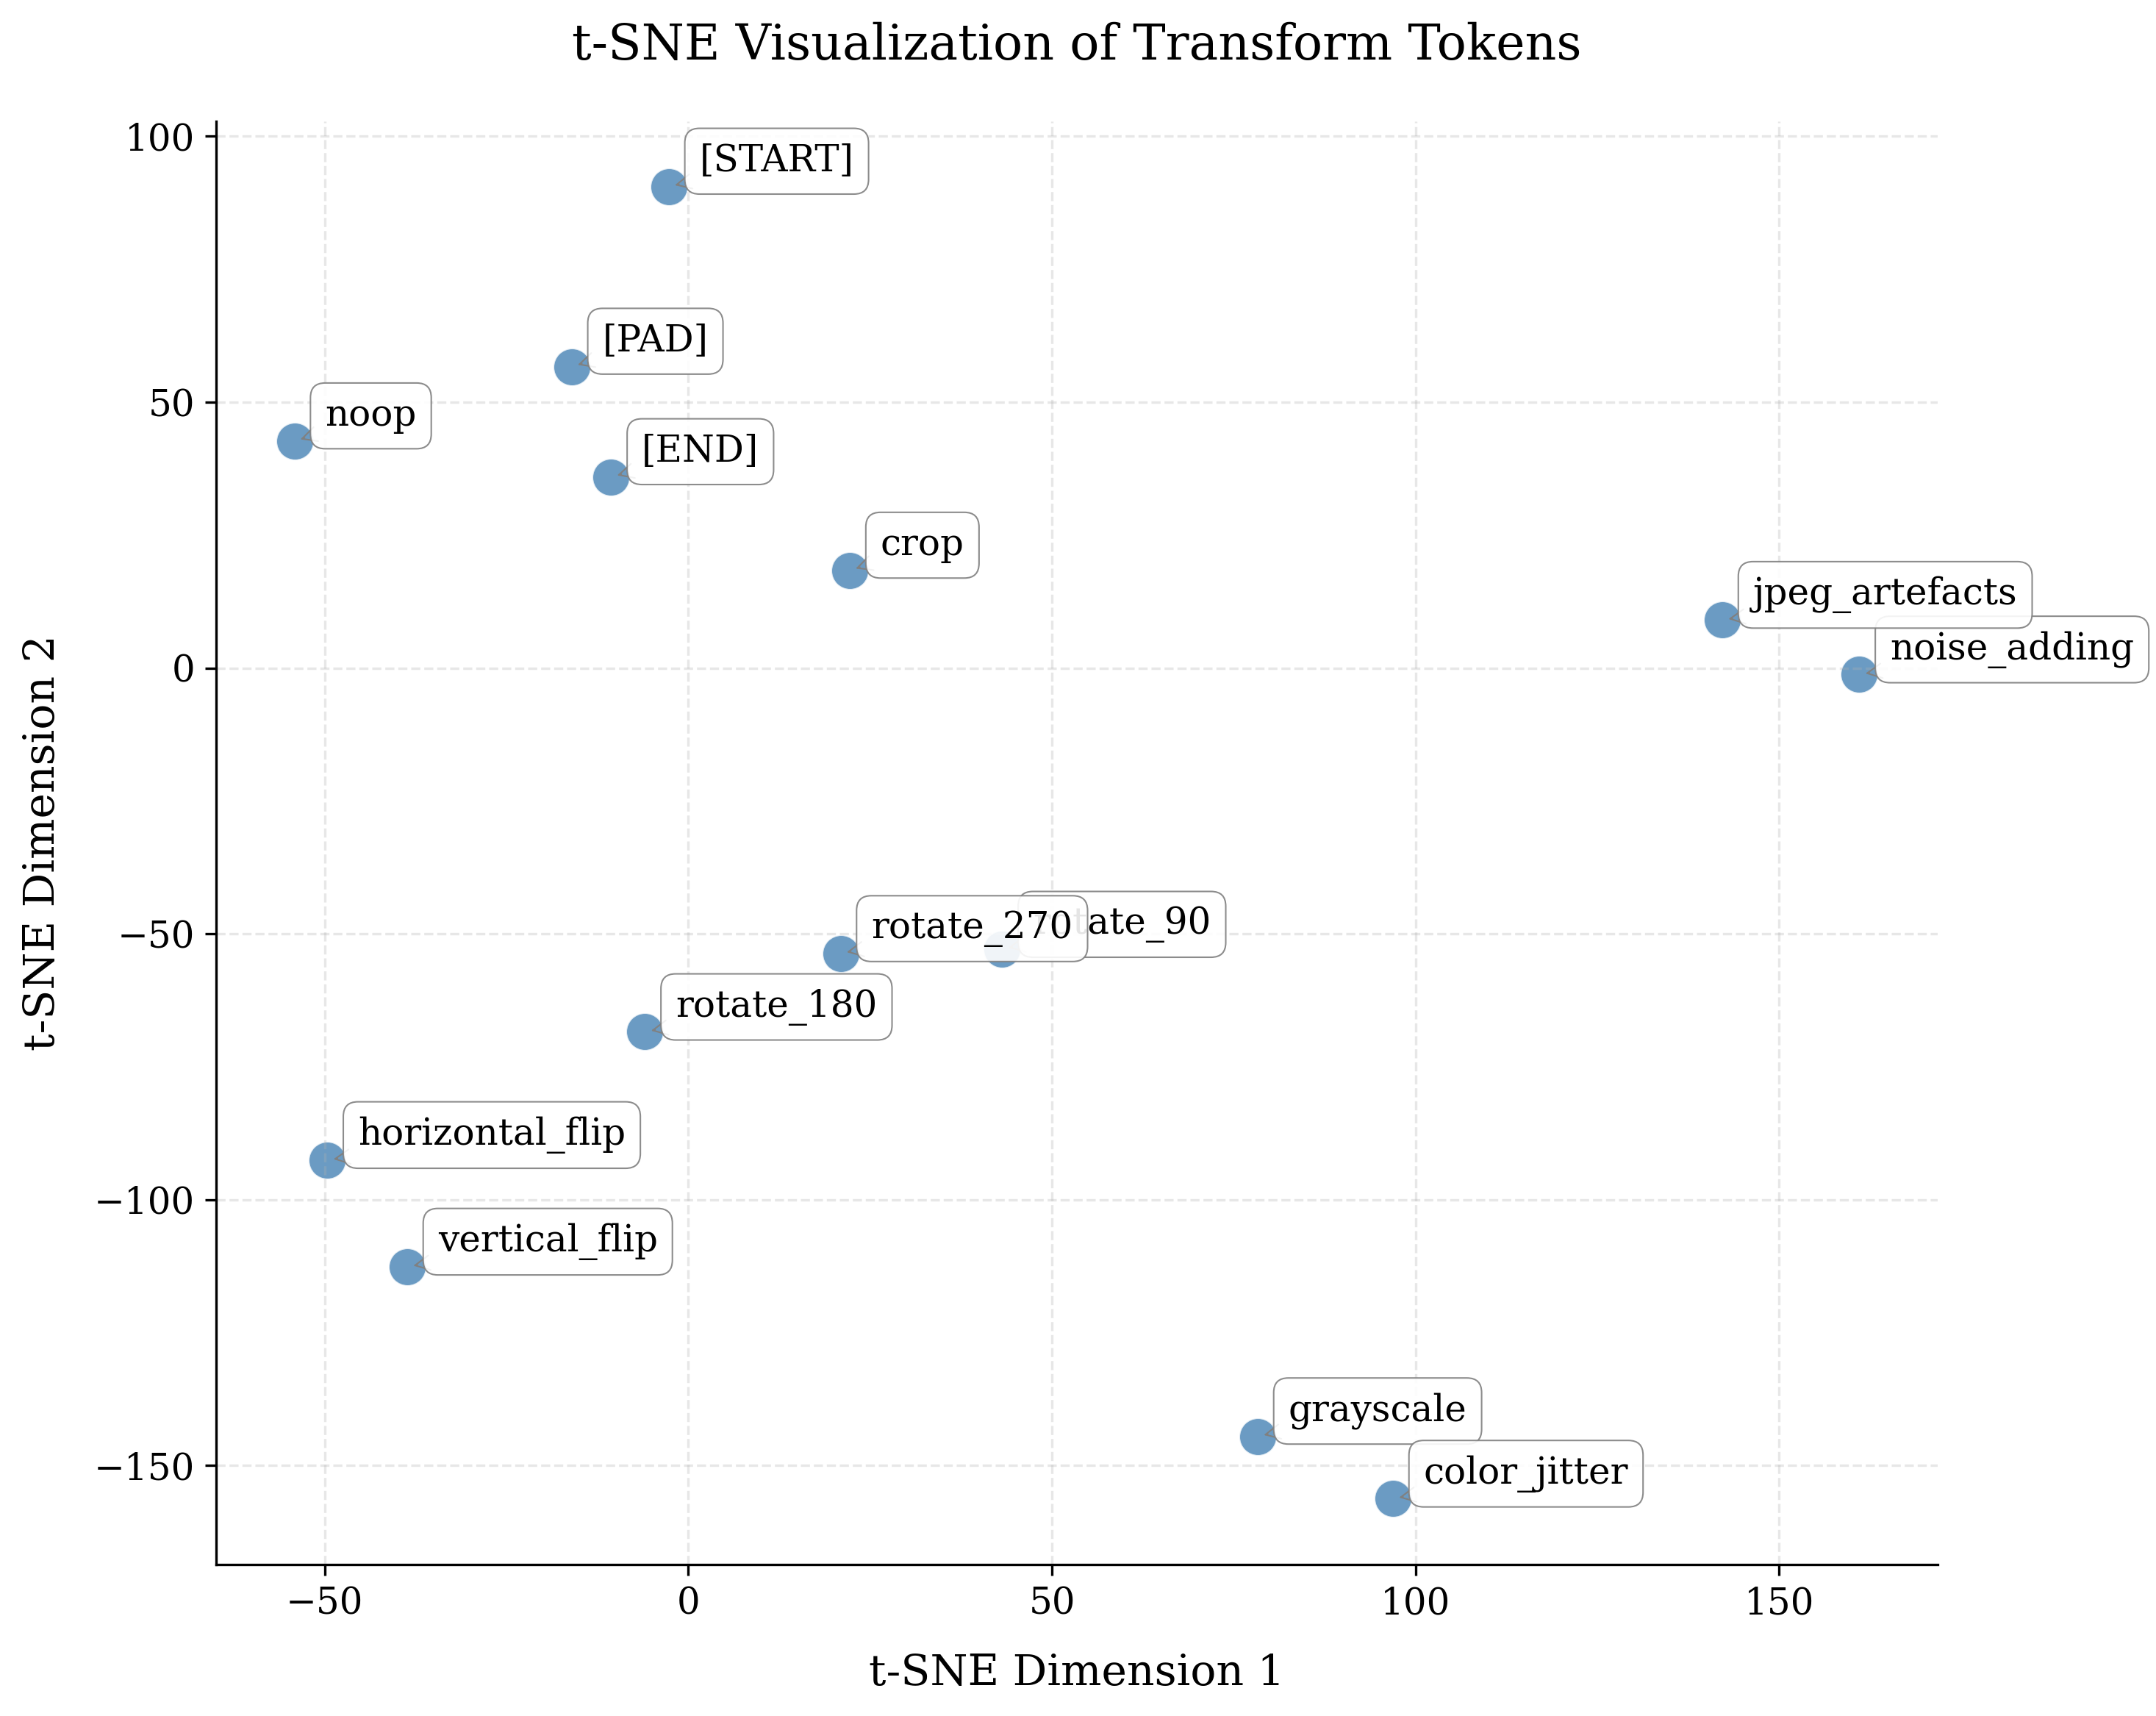

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

plt.rcParams.update({
    'text.usetex': False,
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],  # ← Ключевое исправление
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'lines.linewidth': 1.5,
    'lines.markersize': 8,
    'grid.alpha': 0.3,
    'figure.dpi': 300,
    'font.weight': 'normal',
})

# Создаём фигуру
plt.figure(figsize=(10, 8))

# t-SNE
tsne = TSNE(n_components=2, perplexity=3, random_state=42)
vectors_2d = tsne.fit_transform(vectors_np)

# Отрисовка точек
scatter = plt.scatter(
    vectors_2d[:, 0],
    vectors_2d[:, 1],
    c="#4682B4",
    alpha=0.8,
    s=150,
    edgecolors="white",
    linewidths=0.5,
)

# Аннотации для выбранных токенов
transform_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
for i in transform_indices:
    if i < num_vectors:
        token_name = INVERTED_TRANSFORM_TOKENS.get(i, f"token_{i}")
        plt.annotate(
            token_name,
            (vectors_2d[i, 0], vectors_2d[i, 1]),
            fontsize=12,
            color="black",
            bbox=dict(
                boxstyle="round,pad=0.4",
                fc="white",
                alpha=0.9,
                ec="gray",
                lw=0.5,
            ),
            xytext=(10, 5),
            textcoords="offset points",
            arrowprops=dict(
                arrowstyle="->",
                lw=0.5,
                color="gray",
            ),
        )

plt.title(
    "t-SNE Visualization of Transform Tokens",
    fontsize=16,
    pad=20,
    fontweight='normal',
)
plt.xlabel("t-SNE Dimension 1", fontsize=14, labelpad=10)
plt.ylabel("t-SNE Dimension 2", fontsize=14, labelpad=10)

plt.grid(True, alpha=0.3, which="both", linestyle="--")

sns.despine()

plt.tight_layout()
# plt.savefig(
#     "assets/figure.pdf",
#     format="pdf",
#     dpi=300,
#     bbox_inches="tight",
#     facecolor="white",
# )
plt.show()

### TransformTokenizer

In [ ]:
tokenizer = TransformTokenizer()

# Encoding
seq = ["grayscale", "rotate_90", "noop"]
ids, targets = tokenizer.encode(seq, add_special_tokens=True, max_seq_len=15, return_targets=True)
print(ids)
print(targets)

# Decoding
tokens = tokenizer.decode(ids, skip_special_tokens=True)
print(tokens)  # ['grayscale', 'rotate_90', 'crop']

### Augmentation

In [ ]:
it = ImageTransformer()

In [ ]:
image = Image.open('assets/dog.jpg')

In [ ]:
transformed_image, sequence = it.transform(image, p=0.5)
print(sequence)
transformed_image

In [ ]:
transformed_image, sequence = it.transform_by_length(image, k=5)
print(sequence)
transformed_image

In [ ]:
input_ids, targets = tokenizer.encode(
    sequence,
    add_special_tokens=True,
    return_targets=True
)  # input_ids: [T], targets: [T]

#### Order matters

In [ ]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def apply_transforms(image_path, transforms):
    img = Image.open(image_path)
    for transform in transforms:
        if transform == 'vertical_flip':
            img = ImageOps.flip(img)
        elif transform == 'horizontal_flip':
            img = ImageOps.mirror(img)
        elif transform == 'rotate_90':
            img = img.rotate(90, expand=True)
    return img

image_path = 'assets/image.jpg'

seq1 = ['vertical_flip', 'rotate_90', 'horizontal_flip']
seq2 = ['rotate_90', 'horizontal_flip', 'vertical_flip']

img1 = apply_transforms(image_path, seq1)
img2 = apply_transforms(image_path, seq2)

title1 = "Seq: vertical_flip, rotate_90, horizontal_flip"
title2 = "Seq: rotate_90, horizontal_flip, vertical_flip"

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img1)
axes[0].axis('off')
axes[0].set_title(title1, fontsize=12)

axes[1].imshow(img2)
axes[1].axis('off')
axes[1].set_title(title2, fontsize=12)

plt.tight_layout()
plt.show()

### Dataset

In [ ]:
tokenizer = TransformTokenizer()
transformer = ImageTransformer()
data_path = "data"

In [ ]:
train_data = DomainNetDataset(data_path, tokenizer, transformer, split='train')
print(len(train_data))

In [ ]:
dataloaders = get_domainnet_dataloaders(data_path, tokenizer, transformer)